Single image reconstruction using autoencoders.


https://youtu.be/kpnGB6Y89OY

This experiment demonstrates a single image reconstruction using an autoencoder. The autoencoder's goal is to learn a compressed representation of the input image and then reconstruct it as accurately as possible from that compressed form.

In [1]:
from matplotlib import pyplot as plt
import numpy as np
import cv2
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Sequential, Model


In [2]:
img_size=1024

In [3]:
img=cv2.imread('messi.jpg', 1)   #Change 1 to 0 for grey images

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) #Changing BGR to RGB to show images in true colors

img=cv2.resize(img,(img_size, img_size))
print(img.shape)

(1024, 1024, 3)


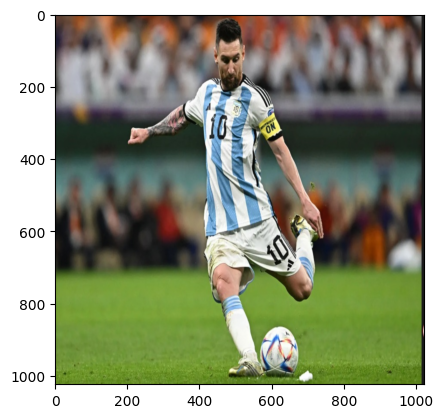

In [4]:
plt.imshow(img)

In [5]:
img_array = np.expand_dims(img, axis=0)
print(img_array.shape)

(1, 1024, 1024, 3)


In [6]:
img_array

array([[[[109,  77,  66],
         [107,  75,  64],
         [106,  74,  63],
         ...,
         [ 26,  26,  26],
         [ 26,  26,  26],
         [ 26,  26,  26]],

        [[109,  77,  66],
         [107,  75,  64],
         [105,  73,  63],
         ...,
         [ 26,  26,  26],
         [ 26,  26,  26],
         [ 26,  26,  26]],

        [[109,  77,  66],
         [107,  75,  64],
         [105,  73,  62],
         ...,
         [ 26,  26,  26],
         [ 26,  26,  26],
         [ 26,  26,  26]],

        ...,

        [[103, 140,  37],
         [ 98, 135,  32],
         [ 97, 134,  31],
         ...,
         [ 25,  26,  28],
         [ 26,  25,  28],
         [ 27,  25,  28]],

        [[105, 142,  39],
         [101, 138,  35],
         [100, 137,  35],
         ...,
         [ 24,  25,  26],
         [ 25,  24,  26],
         [ 26,  24,  26]],

        [[106, 143,  40],
         [103, 140,  37],
         [103, 139,  38],
         ...,
         [ 23,  24,  26],
        

In [7]:
img_array = img_array.astype('float32') / 255.

In [8]:
img_array

array([[[[0.42745098, 0.3019608 , 0.25882354],
         [0.41960785, 0.29411766, 0.2509804 ],
         [0.41568628, 0.2901961 , 0.24705882],
         ...,
         [0.10196079, 0.10196079, 0.10196079],
         [0.10196079, 0.10196079, 0.10196079],
         [0.10196079, 0.10196079, 0.10196079]],

        [[0.42745098, 0.3019608 , 0.25882354],
         [0.41960785, 0.29411766, 0.2509804 ],
         [0.4117647 , 0.28627452, 0.24705882],
         ...,
         [0.10196079, 0.10196079, 0.10196079],
         [0.10196079, 0.10196079, 0.10196079],
         [0.10196079, 0.10196079, 0.10196079]],

        [[0.42745098, 0.3019608 , 0.25882354],
         [0.41960785, 0.29411766, 0.2509804 ],
         [0.4117647 , 0.28627452, 0.24313726],
         ...,
         [0.10196079, 0.10196079, 0.10196079],
         [0.10196079, 0.10196079, 0.10196079],
         [0.10196079, 0.10196079, 0.10196079]],

        ...,

        [[0.40392157, 0.54901963, 0.14509805],
         [0.38431373, 0.5294118 , 0.1254902 ]

Building Autoencoder Model

In [9]:
model = Sequential()

model.add(Conv2D(64, (3, 3),
                 activation='relu',
                 padding='same',
                 input_shape=(img_size, img_size, 3)))

model.add(MaxPooling2D((2, 2),
                       padding='same'))

model.add(Conv2D(128, (3, 3),
                 activation='relu',
                 padding='same'))

model.add(MaxPooling2D((2, 2),
                       padding='same'))

model.add(Conv2D(256, (3, 3),
                 activation='relu',
                 padding='same'))


model.add(MaxPooling2D((2, 2),
                       padding='same'))

model.add(Conv2D(256, (3, 3),
                 activation='relu',
                 padding='same'))
###########################################################
model.add(UpSampling2D((2, 2)))
model.add(Conv2D(128, (3, 3),
                 activation='relu',
                 padding='same'))

model.add(UpSampling2D((2, 2)))

model.add(Conv2D(64, (3, 3),
                 activation='relu',
                 padding='same'))

model.add(UpSampling2D((2, 2)))

model.add(Conv2D(3, (3, 3),
                 activation='sigmoid',
                 padding='same'))

model.compile(optimizer='adam',
              loss='mean_squared_error',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 1024, 1024, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 512, 512, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 512, 512, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 256, 256, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 256, 256, 256)  │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 128, 128, 256)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 256)  │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 256, 256, 256)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 256, 256, 128)  │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 512, 512, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 512, 512, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 1024, 1024, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 1024, 1024, 3)  │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,331,459 (5.08 MB)

 Trainable params: 1,331,459 (5.08 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.fit(img_array, img_array, epochs=1000)

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step - accuracy: 0.3446 - loss: 0.0587
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.4969 - loss: 0.0561
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.4987 - loss: 0.0556
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.5339 - loss: 0.0539
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.6444 - loss: 0.0515
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.5159 - loss: 0.0472
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.4943 - loss: 0.0427
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.5407 - loss: 0.0410
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.5444 - loss: 0.0390
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.5354 - loss: 0.0356
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.5668 - loss: 0.0306
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step 

In [11]:
pred = model.predict(img_array)



1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


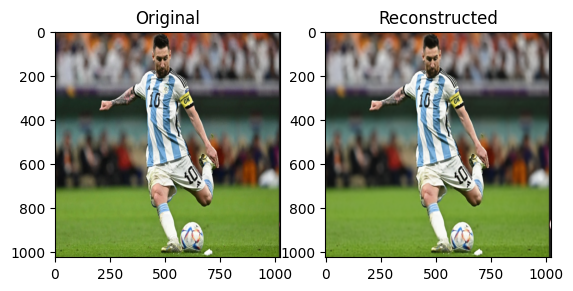

In [12]:
plt.subplot(1,2,1)
plt.imshow(img)
plt.title('Original')
plt.subplot(1,2,2)
plt.imshow(pred[0].reshape(img_size,img_size,3))
plt.title('Reconstructed')
plt.show()